## 0 · Environment Setup & Imports

Consolidate **all** imports and seeds in one place so the notebook can be re-run cleanly from top to bottom.

In [ ]:
import os, random
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import pandas as pd
from PIL import Image, UnidentifiedImageError

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, f1_score
)

from tensorflow.keras import Input, Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Dropout, BatchNormalization,
    RandomFlip, RandomRotation, RandomZoom
)
from tensorflow.keras.applications import EfficientNetB0, ResNet50, DenseNet121
from tensorflow.keras.applications.efficientnet   import preprocess_input as effnet_preprocess
from tensorflow.keras.applications.resnet50       import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet       import preprocess_input as densenet_preprocess


TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1 · Download Dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
dataset_dir = Path(path) / "chest_xray"
print("Dataset root:", dataset_dir)
print("Top-level dirs:", [d.name for d in sorted(dataset_dir.iterdir())])


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset root: /kaggle/input/chest-xray-pneumonia/chest_xray
Top-level dirs: ['__MACOSX', 'chest_xray', 'test', 'train', 'val']


## 2 · Exploratory Data Analysis

In [ ]:
records = [
    {"filepath": str(img), "label": label, "split": split}
    for split in ("train", "val", "test")
    for label in ("NORMAL", "PNEUMONIA")
    for img in (dataset_dir / split / label).glob("*")
    if img.suffix.lower() in {".jpg", ".jpeg", ".png"}   # skip hidden files
]

df = pd.DataFrame(records)
print(f"Total images found: {len(df)}")
df.groupby(["split", "label"]).size().unstack(fill_value=0)


Total images found: 5856


label,NORMAL,PNEUMONIA
split,,
test,234,390
train,1341,3875
val,8,8


In [ ]:
def get_dims(fp):
  """Return (width, height) for one image path."""
  with Image.open(fp) as img:
        return img.width, img.height

with ThreadPoolExecutor() as ex:
    dims = list(ex.map(get_dims, df["filepath"]))

df[["width", "height"]] = pd.DataFrame(dims, index=df.index)
df["aspect_ratio"] = df["width"] / df["height"]
print(df[["width", "height", "aspect_ratio"]].describe().round(1))


        width  height  aspect_ratio
count  5856.0  5856.0        5856.0
mean   1327.9   970.7           1.4
std     363.5   383.4           0.3
min     384.0   127.0           0.8
25%    1056.0   688.0           1.3
50%    1281.0   888.0           1.4
75%    1560.0  1187.0           1.6
max    2916.0  2713.0           3.4


In [ ]:
bad_files = []
for fp in df["filepath"]:
    try:
        with Image.open(fp) as img:
            img.verify()
        with Image.open(fp) as img:
            img.load()
    except (UnidentifiedImageError, OSError) as e:
        bad_files.append((fp, str(e)))

print(f"Corrupt/unreadable files: {len(bad_files)}")
if bad_files:
    print("Dropping:", bad_files)
    df = df[~df["filepath"].isin([b[0] for b in bad_files])].reset_index(drop=True)


Corrupt/unreadable files: 0


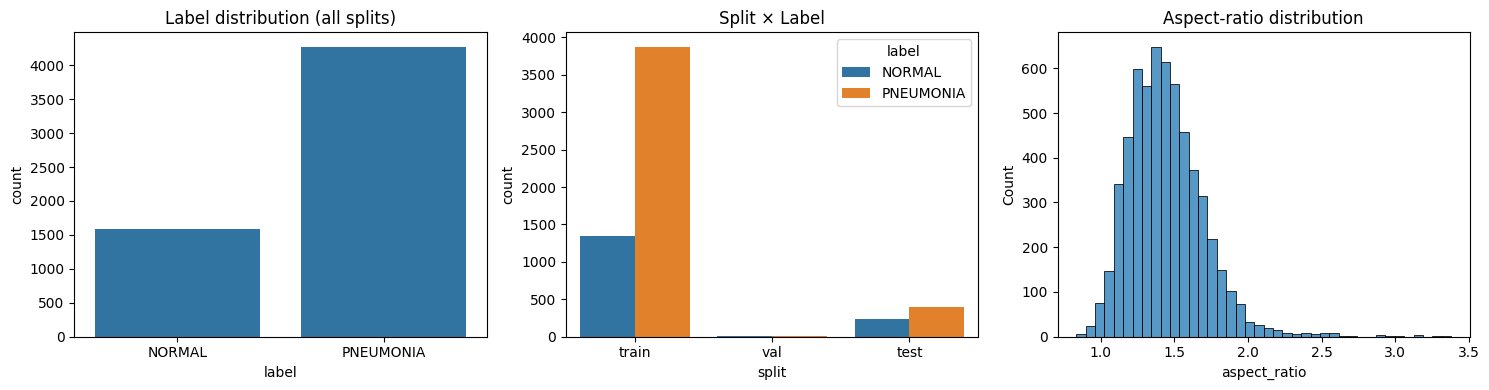

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x="label", ax=axes[0])
axes[0].set_title("Label distribution (all splits)")

sns.countplot(data=df, x="split", hue="label", ax=axes[1])
axes[1].set_title("Split × Label")

sns.histplot(df["aspect_ratio"], bins=40, ax=axes[2])
axes[2].set_title("Aspect-ratio distribution")

plt.tight_layout()
plt.show()


## 3 · Split Preparation

The original `val` folder has only **16** images—far too few for a reliable validation signal.  
We merge it back into `train` and create a proper 80/20 stratified split.


In [ ]:
# Merge tiny val into train, then re-split
df["split"] = df["split"].replace("val", "train")

train_val_df = df[df["split"] == "train"].copy()
test_df      = df[df["split"] == "test"].copy()

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.20,
    stratify=train_val_df["label"],
    random_state=SEED
)

# Map string labels to 0/1
label_map = {"NORMAL": 0, "PNEUMONIA": 1}
for subset in (train_df, val_df, test_df):
    subset["target"] = subset["label"].map(label_map)

print("Train:", train_df["label"].value_counts().to_dict())
print("Val  :", val_df["label"].value_counts().to_dict())
print("Test :", test_df["label"].value_counts().to_dict())


Train: {'PNEUMONIA': 3106, 'NORMAL': 1079}
Val  : {'PNEUMONIA': 777, 'NORMAL': 270}
Test : {'PNEUMONIA': 390, 'NORMAL': 234}


## 4 · tf.data Pipelines

We define **two** preprocessing functions:
- `load_image_cnn` – scales to [0, 1] for the custom CNN.  
- `load_image_transfer(preprocess_fn)` – applies the backbone-specific  
  `preprocess_input` (ResNet expects mean-subtracted BGR; EfficientNet  
  expects [0, 255]; DenseNet does its own normalisation).  




In [ ]:
IMG_SIZE   = 224
BATCH_SIZE = 32

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    return img, label

def _read_and_resize(path):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img

def load_image_cnn(path, label):
    """Normalise to [0, 1] for the custom CNN."""
    img = _read_and_resize(path)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_transfer_loader(preprocess_fn):
    """Return a loader that applies backbone-specific preprocessing."""
    def load_fn(path, label):
        img = _read_and_resize(path)
        img = tf.cast(img, tf.float32)
        img = preprocess_fn(img)
        return img, label
    return load_fn

def make_ds(df_subset, load_fn, augment_data=False, shuffle=False):
    """Generic pipeline builder."""
    ds = tf.data.Dataset.from_tensor_slices(
        (df_subset["filepath"].values, df_subset["target"].values)
    )
    ds = ds.map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df_subset), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_cnn = make_ds(train_df, load_image_cnn, augment_data=True,  shuffle=True)
val_ds_cnn   = make_ds(val_df,   load_image_cnn, augment_data=False, shuffle=False)
test_ds_cnn  = make_ds(test_df,  load_image_cnn, augment_data=False, shuffle=False)

for imgs, lbls in train_ds_cnn.take(1):
    print("Batch shape:", imgs.shape, "| Labels:", lbls.numpy()[:8])
    print("Pixel range: [{:.3f}, {:.3f}]".format(float(imgs.numpy().min()), float(imgs.numpy().max())))


Batch shape: (32, 224, 224, 3) | Labels: [0 1 1 1 1 0 1 1]
Pixel range: [-0.191, 1.210]


## 5 · Class Weights
Mitigate the ~3:1 PNEUMONIA:NORMAL imbalance during training.

In [ ]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["target"]),
    y=train_df["target"]
)
class_weights = dict(enumerate(weights))
print("Class weights:", {k: f"{v:.3f}" for k, v in class_weights.items()})


Class weights: {0: '1.939', 1: '0.674'}


## 6 · Callbacks Factory



In [ ]:
def make_callbacks(monitor="val_loss", patience_es=7, patience_lr=3,
                   lr_factor=0.5, ckpt_path=None):
    """
    Returns a fresh list of callbacks for each training run.

    patience_es : EarlyStopping patience
    patience_lr : ReduceLROnPlateau patience
    lr_factor   : LR reduction multiplier (0.5 = halve; original was 0.2 = too aggressive)
    ckpt_path   : if given, saves best weights to disk
    """
    cbs = [
        tf.keras.callbacks.EarlyStopping(
            monitor=monitor,
            patience=patience_es,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor=monitor,
            factor=lr_factor,
            patience=patience_lr,
            min_lr=1e-7,
            verbose=1
        ),
    ]
    if ckpt_path:
        cbs.append(
            tf.keras.callbacks.ModelCheckpoint(
                filepath=ckpt_path,
                monitor=monitor,
                save_best_only=True,
                verbose=1
            )
        )
    return cbs


## 7 · Custom CNN
A four-block ConvNet with BatchNorm and a GAP head.

In [ ]:
def build_cnn():
    return Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        Conv2D(32,  (3, 3), padding="same", activation="relu"),
        BatchNormalization(), MaxPooling2D(),

        Conv2D(64,  (3, 3), padding="same", activation="relu"),
        BatchNormalization(), MaxPooling2D(),

        Conv2D(128, (3, 3), padding="same", activation="relu"),
        BatchNormalization(), MaxPooling2D(),

        Conv2D(256, (3, 3), padding="same", activation="relu"),
        BatchNormalization(), MaxPooling2D(),

        GlobalAveragePooling2D(),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.4),
        Dense(1, activation="sigmoid"),
    ], name="CustomCNN")

cnn_model = build_cnn()
cnn_model.summary()


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,873 (1.62 MB)

 Trainable params: 422,657 (1.61 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [ ]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_cnn = cnn_model.fit(
    train_ds_cnn,
    validation_data=val_ds_cnn,
    epochs=40,
    class_weight=class_weights,
    callbacks=make_callbacks(patience_es=8, ckpt_path="cnn_best.keras"),
)


Epoch 1/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.7451 - auc: 0.8579 - loss: 0.5231 - precision: 0.9471 - recall: 0.6918
Epoch 1: val_loss improved from None to 1.97971, saving model to cnn_best.keras

Epoch 1: finished saving model to cnn_best.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 71s 210ms/step - accuracy: 0.7881 - auc: 0.8879 - loss: 0.4492 - precision: 0.9598 - recall: 0.7457 - val_accuracy: 0.7421 - val_auc: 0.5000 - val_loss: 1.9797 - val_precision: 0.7421 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8339 - auc: 0.9101 - loss: 0.3912 - precision: 0.9531 - recall: 0.8147
Epoch 2: val_loss did not improve from 1.97971
131/131 ━━━━━━━━━━━━━━━━━━━━ 44s 121ms/step - accuracy: 0.8342 - auc: 0.9116 - loss: 0.3835 - precision: 0.9497 - recall: 0.8200 - val_accuracy: 0.7421 - val_auc: 0.5000 - val_loss: 3.3989 - val_precision: 0.7421 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/40
131/131 ━━━━━━━━━━━

## 8 · Evaluate Custom CNN

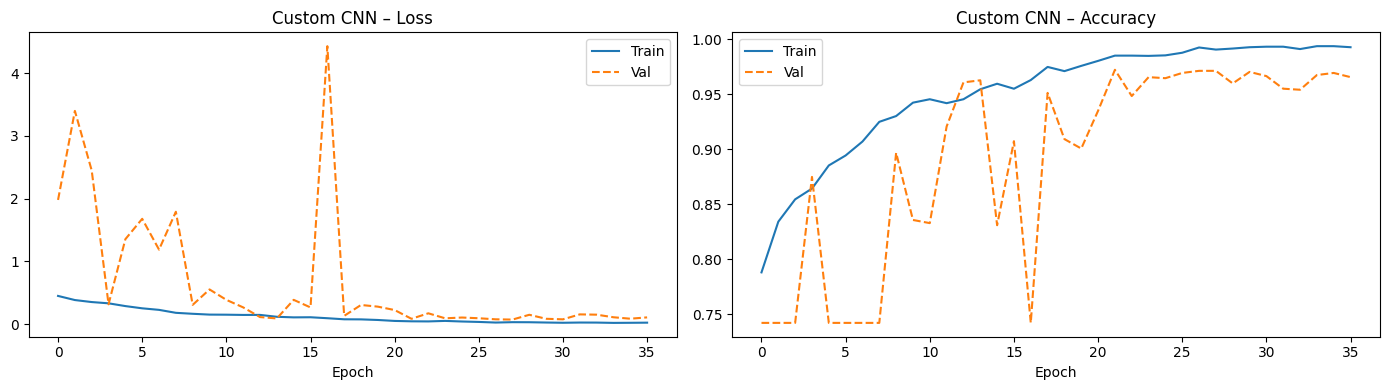

In [ ]:
def plot_history(history, title=""):
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, metric, val_metric in zip(
        axes,
        ["loss", "accuracy"],
        ["val_loss", "val_accuracy"]
    ):
        ax.plot(h[metric],     label="Train")
        ax.plot(h[val_metric], label="Val",  linestyle="--")
        ax.set_title(f"{title} – {metric.capitalize()}")
        ax.legend(); ax.set_xlabel("Epoch")
    plt.tight_layout(); plt.show()

plot_history(history_cnn, title="Custom CNN")



Custom CNN
  ROC-AUC       : 0.9074
  Optimal thresh: 0.997  (default 0.5)

── At threshold = 0.50 ──
              precision    recall  f1-score   support

      NORMAL       0.99      0.31      0.47       234
   PNEUMONIA       0.71      1.00      0.83       390

    accuracy                           0.74       624
   macro avg       0.85      0.65      0.65       624
weighted avg       0.81      0.74      0.70       624

── At threshold = 0.997 (optimal) ──
              precision    recall  f1-score   support

      NORMAL       0.73      0.88      0.80       234
   PNEUMONIA       0.92      0.80      0.86       390

    accuracy                           0.83       624
   macro avg       0.82      0.84      0.83       624
weighted avg       0.85      0.83      0.83       624



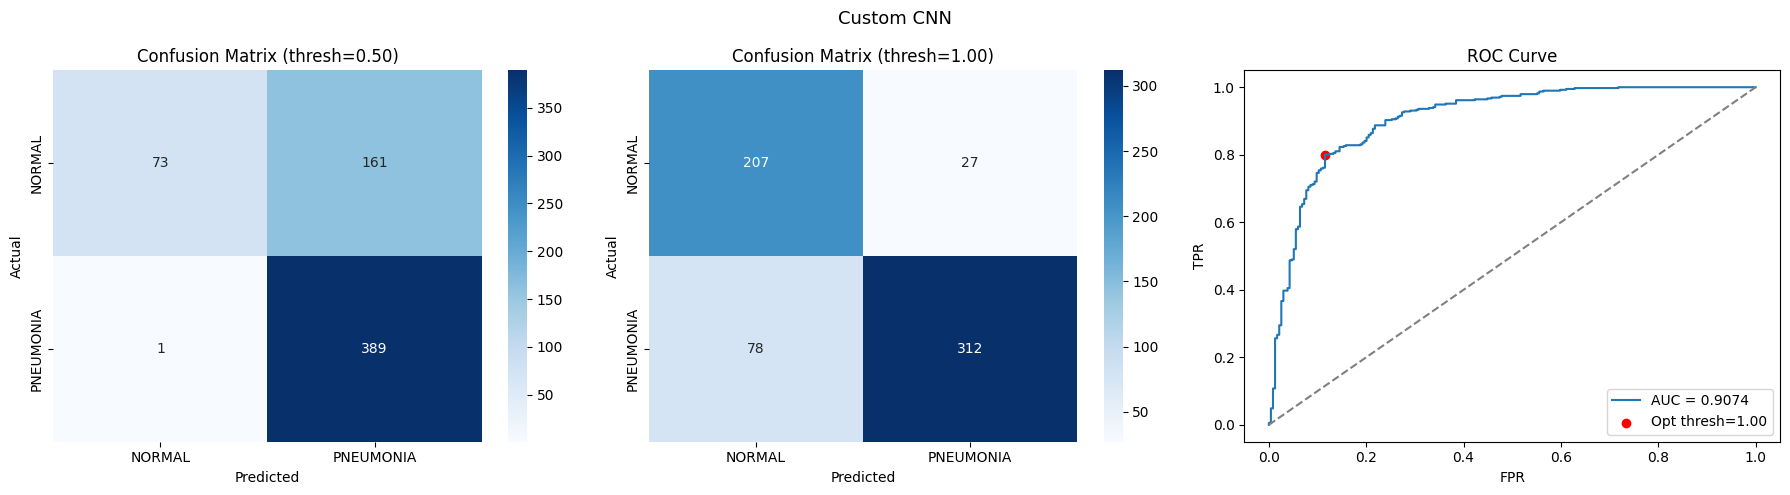

In [ ]:
def full_evaluation(model, test_ds, model_name="Model"):
    """
    Returns a dict of metrics and prints all diagnostic plots.
    FIX: replaced per-batch model.predict() loop with a single
         model.predict(test_ds) call — cleaner and faster.
    """
    # Collect ground truth
    y_true = np.concatenate([lbls.numpy() for _, lbls in test_ds])

    # One-shot prediction
    y_prob = model.predict(test_ds, verbose=0).flatten()

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    opt_thresh = float(thresholds[np.argmax(j_scores)])
    roc_auc = auc(fpr, tpr)
    print(f"\n{model_name}")
    print(f"  ROC-AUC       : {roc_auc:.4f}")
    print(f"  Optimal thresh: {opt_thresh:.3f}  (default 0.5)")

    y_pred_05  = (y_prob >= 0.50).astype(int)
    y_pred_opt = (y_prob >= opt_thresh).astype(int)

    print("\n── At threshold = 0.50 ──")
    print(classification_report(y_true, y_pred_05, target_names=["NORMAL","PNEUMONIA"]))
    print(f"── At threshold = {opt_thresh:.3f} (optimal) ──")
    print(classification_report(y_true, y_pred_opt, target_names=["NORMAL","PNEUMONIA"]))

    # Confusion matrix
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, y_pred, thresh in zip(axes[:2], [y_pred_05, y_pred_opt], [0.50, opt_thresh]):
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["NORMAL","PNEUMONIA"],
                    yticklabels=["NORMAL","PNEUMONIA"], ax=ax)
        ax.set_title(f"Confusion Matrix (thresh={thresh:.2f})")
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

    # ROC curve
    axes[2].plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    axes[2].plot([0,1],[0,1], linestyle="--", color="grey")
    axes[2].scatter(fpr[np.argmax(j_scores)], tpr[np.argmax(j_scores)],
                    marker="o", color="red", label=f"Opt thresh={opt_thresh:.2f}")
    axes[2].set_xlabel("FPR"); axes[2].set_ylabel("TPR")
    axes[2].set_title("ROC Curve"); axes[2].legend()
    plt.suptitle(model_name, fontsize=13); plt.tight_layout(); plt.show()

    f1 = f1_score(y_true, y_pred_opt)
    return {
        "Model": model_name, "AUC": roc_auc, "F1": f1,
        "Optimal_Threshold": opt_thresh,
        "Recall_opt": float(np.sum((y_true==1) & (y_pred_opt==1)) / np.sum(y_true==1)),
        "Precision_opt": float(np.sum((y_true==1) & (y_pred_opt==1)) / (np.sum(y_pred_opt==1) + 1e-9)),
    }

cnn_results = full_evaluation(cnn_model, test_ds_cnn, "Custom CNN")


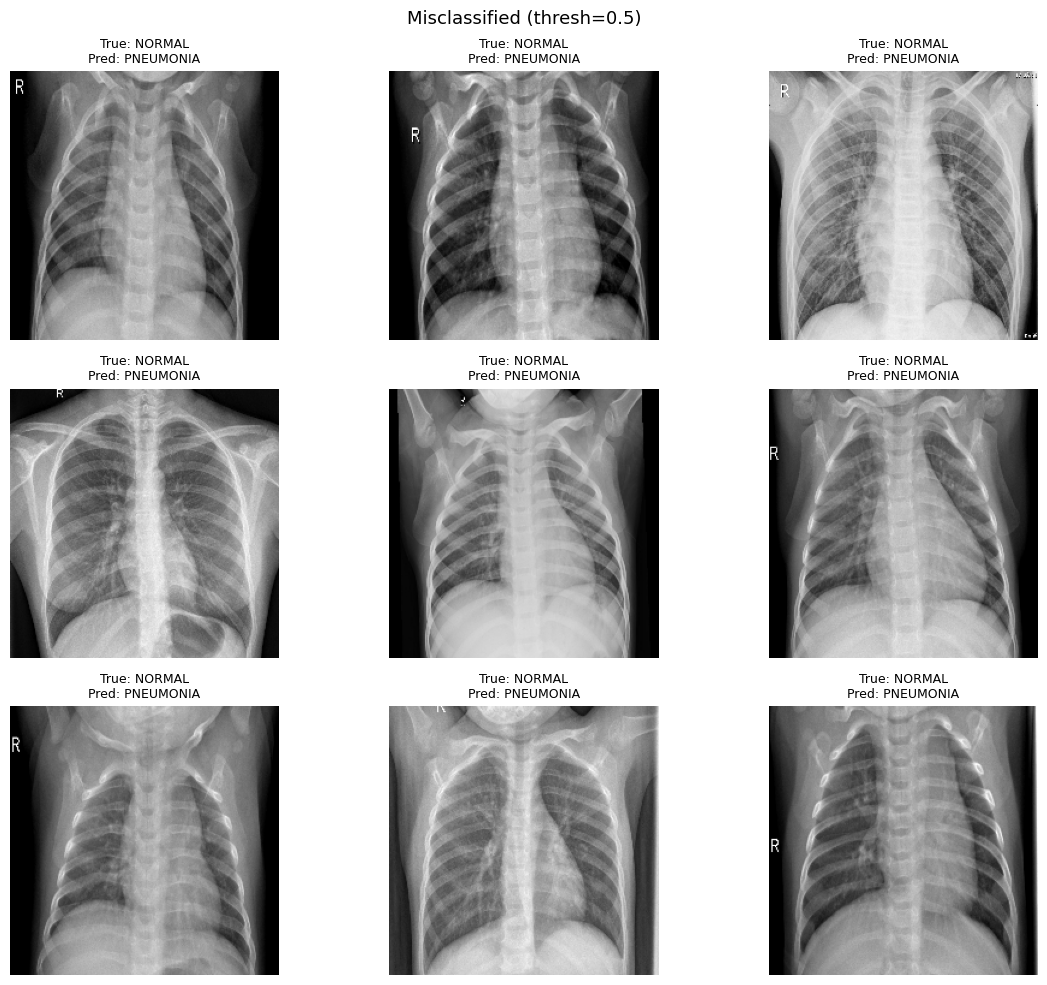

Total misclassified: 162


In [ ]:
# ── Misclassified samples ───────────────────────────────────────────
def show_misclassified(model, test_ds, threshold=0.5, n=9):
    misclassified = []
    for imgs, lbls in test_ds:
        preds = model.predict(imgs, verbose=0).flatten()
        pred_lbls = (preds >= threshold).astype(int)
        for img, true, pred in zip(imgs.numpy(), lbls.numpy(), pred_lbls):
            if true != pred:
                misclassified.append((img, true, pred))

    n = min(n, len(misclassified))
    fig, axes = plt.subplots(3, 3, figsize=(12, 10))
    label_names = {0: "NORMAL", 1: "PNEUMONIA"}
    for ax, (img, true, pred) in zip(axes.flatten(), misclassified[:n]):
        ax.imshow(np.clip(img, 0, 1))
        ax.set_title(f"True: {label_names[true]}\nPred: {label_names[pred]}", fontsize=9)
        ax.axis("off")
    for ax in axes.flatten()[n:]:
        ax.axis("off")
    plt.suptitle(f"Misclassified (thresh={threshold})", fontsize=13)
    plt.tight_layout(); plt.show()
    print(f"Total misclassified: {len(misclassified)}")

show_misclassified(cnn_model, test_ds_cnn)


## 9 · Transfer Learning


In [ ]:
# ── Build backbone-specific datasets ───────────────────────────────
def make_transfer_datasets(preprocess_fn):
    loader = make_transfer_loader(preprocess_fn)
    return (
        make_ds(train_df, loader, augment_data=True,  shuffle=True),
        make_ds(val_df,   loader, augment_data=False, shuffle=False),
        make_ds(test_df,  loader, augment_data=False, shuffle=False),
    )

effnet_train_ds, effnet_val_ds, effnet_test_ds  = make_transfer_datasets(effnet_preprocess)
resnet_train_ds, resnet_val_ds, resnet_test_ds  = make_transfer_datasets(resnet_preprocess)
dense_train_ds,  dense_val_ds,  dense_test_ds   = make_transfer_datasets(densenet_preprocess)
print("Backbone-specific datasets ready.")


Backbone-specific datasets ready.


In [ ]:
def build_transfer_model(backbone, name):
    """
    Phase-1 model: backbone fully frozen, only head trains.
    Augmentation is NOT inside the model—it lives in the tf.data pipeline.
    """
    backbone.trainable = False

    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation="sigmoid")(x)

    return Model(inputs, outputs, name=name)

def compile_model(model, lr=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ]
    )
    return model

effnet_base  = EfficientNetB0(include_top=False, weights="imagenet")
resnet_base  = ResNet50(include_top=False, weights="imagenet")
densenet_base = DenseNet121(include_top=False, weights="imagenet")

effnet_model  = compile_model(build_transfer_model(effnet_base,  "EfficientNetB0"))
resnet_model  = compile_model(build_transfer_model(resnet_base,  "ResNet50"))
densenet_model = compile_model(build_transfer_model(densenet_base, "DenseNet121"))


In [ ]:
# ── Phase 1: train head only ─────────────────────────────────────
PHASE1_EPOCHS = 15

history_effnet  = effnet_model.fit(
    effnet_train_ds, validation_data=effnet_val_ds,
    epochs=PHASE1_EPOCHS, class_weight=class_weights,
    callbacks=make_callbacks(patience_es=5, ckpt_path="effnet_phase1.keras")
)
history_resnet  = resnet_model.fit(
    resnet_train_ds, validation_data=resnet_val_ds,
    epochs=PHASE1_EPOCHS, class_weight=class_weights,
    callbacks=make_callbacks(patience_es=5, ckpt_path="resnet_phase1.keras")
)
history_dense   = densenet_model.fit(
    dense_train_ds, validation_data=dense_val_ds,
    epochs=PHASE1_EPOCHS, class_weight=class_weights,
    callbacks=make_callbacks(patience_es=5, ckpt_path="densenet_phase1.keras")
)


In [ ]:
# ── Phase 2: partial unfreeze (fine-tuning) ──────────────────────
def fine_tune(model, backbone, unfreeze_from, train_ds, val_ds,
              epochs=10, lr=1e-5, ckpt_prefix="ft"):
    """Unfreeze top layers of backbone and retrain with a tiny LR."""
    backbone.trainable = True
    for layer in backbone.layers[:unfreeze_from]:
        layer.trainable = False

    compile_model(model, lr=lr)
    return model.fit(
        train_ds, validation_data=val_ds,
        epochs=epochs, class_weight=class_weights,
        callbacks=make_callbacks(patience_es=5, lr_factor=0.3,
                                 ckpt_path=f"{ckpt_prefix}_best.keras")
    )

history_effnet_ft = fine_tune(
    effnet_model, effnet_base,
    unfreeze_from=int(len(effnet_base.layers) * 0.7),
    train_ds=effnet_train_ds, val_ds=effnet_val_ds,
    ckpt_prefix="effnet_ft"
)
history_resnet_ft = fine_tune(
    resnet_model, resnet_base,
    unfreeze_from=int(len(resnet_base.layers) * 0.7),
    train_ds=resnet_train_ds, val_ds=resnet_val_ds,
    ckpt_prefix="resnet_ft"
)
history_dense_ft  = fine_tune(
    densenet_model, densenet_base,
    unfreeze_from=int(len(densenet_base.layers) * 0.7),
    train_ds=dense_train_ds, val_ds=dense_val_ds,
    ckpt_prefix="densenet_ft"
)


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.6612 - auc: 0.7080 - loss: 0.6748 - precision: 0.8442 - recall: 0.6610
Epoch 1: val_loss improved from None to 0.46871, saving model to effnet_ft_best.keras

Epoch 1: finished saving model to effnet_ft_best.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 136s 459ms/step - accuracy: 0.7140 - auc: 0.8005 - loss: 0.5618 - precision: 0.8920 - recall: 0.6993 - val_accuracy: 0.8195 - val_auc: 0.9555 - val_loss: 0.4687 - val_precision: 0.9884 - val_recall: 0.7658 - learning_rate: 1.0000e-05
Epoch 2/10
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8133 - auc: 0.9177 - loss: 0.3793 - precision: 0.9552 - recall: 0.7835
Epoch 2: val_loss improved from 0.46871 to 0.40403, saving model to effnet_ft_best.keras

Epoch 2: finished saving model to effnet_ft_best.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 118ms/step - accuracy: 0.8237 - auc: 0.9257 - loss: 0.3622 - precision: 0.9607 - recall: 0.7949 - val_accuracy: 0.8357 - val_auc: 0.9695 - v

## 10 · Compare All Models

In [ ]:
# Evaluate each model on its backbone-specific test set
eval_pairs = [
    (cnn_model,     test_ds_cnn,     "Custom CNN"),
    (effnet_model,  effnet_test_ds,  "EfficientNetB0"),
    (resnet_model,  resnet_test_ds,  "ResNet50"),
    (densenet_model, dense_test_ds,  "DenseNet121"),
]

all_results = []
for m, ds, name in eval_pairs:
    r = full_evaluation(m, ds, name)
    all_results.append(r)

comparison_df = (
    pd.DataFrame(all_results)
    .sort_values("AUC", ascending=False)
    .reset_index(drop=True)
)
print("\n=== Model Comparison ===")
print(comparison_df.to_string(index=False))
